In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,MinMaxScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

In [3]:
df = pd.read_csv(r"E:\SEM 1\Applied ML\insurance.csv")

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Use iloc for position-based indexing and slicing.
# df.iloc[row_index, column_index]
df.iloc[0,2]  
df.iloc[1,:]
df.iloc[2:4,4:6]
df.iloc[0]

age                19
sex            female
bmi              27.9
children            0
smoker            yes
region      southwest
charges     16884.924
Name: 0, dtype: object

In [7]:
# Use loc for label-based indexing and slicing.
# df.loc[row_label, 'column_name']
df.loc[0,'age']
df.loc[:,'age']
df.loc[3,:]

age                  33
sex                male
bmi              22.705
children              0
smoker               no
region        northwest
charges     21984.47061
Name: 3, dtype: object

In [8]:
#  Extract data using the query method with string expressions.
#  • df.query('column_name > value'
df.query('age < 19')

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
22,18,male,34.100,0,no,southeast,1137.01100
31,18,female,26.315,0,no,northeast,2198.18985
46,18,female,38.665,2,no,northeast,3393.35635
50,18,female,35.625,0,no,northeast,2211.13075
...,...,...,...,...,...,...,...
1296,18,male,26.125,0,no,northeast,1708.92575
1315,18,male,28.310,1,no,northeast,11272.33139
1317,18,male,53.130,0,no,southeast,1163.46270
1334,18,female,31.920,0,no,northeast,2205.98080


In [28]:
num_cols = df.select_dtypes(exclude = ['object']).columns.tolist()
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()

In [29]:
cat_cols

['sex', 'smoker', 'region']

In [30]:
num_cols

['age', 'bmi', 'children', 'charges']

In [32]:
num_cols.remove('charges')

In [33]:
num_cols

['age', 'bmi', 'children']

In [23]:
target = df['charges']

In [38]:
df1 = df.drop(columns = ['charges'],axis = 1)

In [40]:
df1

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [13]:
df['region'].mode()[0]

str

In [15]:
type(df['bmi'].mean())

numpy.float64

In [31]:
df['sex'].str.upper()   # many more string methods - refer python ppt of LnT

0       FEMALE
1         MALE
2         MALE
3         MALE
4         MALE
         ...  
1333      MALE
1334    FEMALE
1335    FEMALE
1336    FEMALE
1337    FEMALE
Name: sex, Length: 1338, dtype: object

In [50]:
st = StandardScaler()

In [51]:
inp_sc = st.fit_transform(df1[num_cols])

In [52]:
inp_sc

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

In [ ]:
# pd.DataFrame(inp_sc,columns = ['a','b','c'])

In [69]:
# Task 3: Perform Principal Component Analysis
pca = PCA(n_components = 3)
pca_data = pca.fit_transform(inp_sc)

In [70]:
pca_data

array([[-1.57229799, -0.5685205 , -0.55297731],
       [-0.73686427, -0.13243526, -1.4090442 ],
       [ 0.18662455,  1.40031789, -1.1345754 ],
       ...,
       [-0.6638586 , -1.08479457, -1.58684105],
       [-1.69846619, -0.45754847, -0.22022975],
       [ 0.62237643, -0.87859851,  1.46367459]])

In [71]:
pca.explained_variance_ratio_

array([0.37399127, 0.33047988, 0.29552885])

In [72]:
# Choosing only top 2 pricipal componets for kmeans
data1 = pca_data[:,:2]

In [73]:
# km=KMeans(init="random",n_clusters=3, n_init=10,max_iter=10,random_state=2)
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(data1)

c:\Users\Girish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [80]:
label = kmeans.fit_predict(data1)

c:\Users\Girish\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [81]:
label

array([1, 1, 0, ..., 1, 1, 2])

In [74]:
kmeans.labels_

array([1, 1, 0, ..., 1, 1, 2])

In [92]:
label == kmeans.labels_

array([ True,  True,  True, ...,  True,  True,  True])

In [75]:
kmeans.cluster_centers_

array([[ 0.43708807,  1.26085102],
       [-1.00075994, -0.25842002],
       [ 0.80218801, -0.7291011 ]])

In [76]:
kmeans.inertia_

1088.7690118823907

In [94]:
sil_score = silhouette_score(data1, label)
sil_score

0.3979928929792575

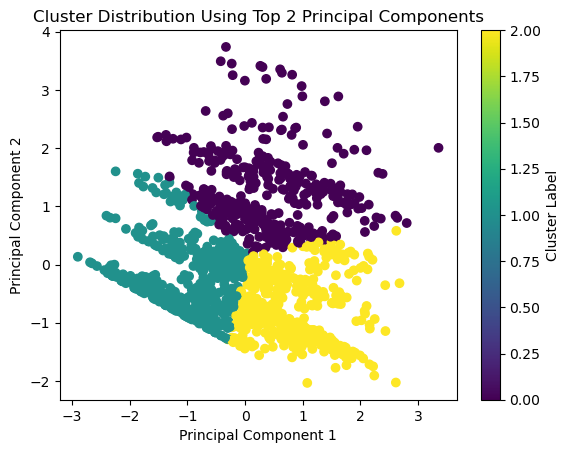

In [95]:
# Task 6: Visualize Cluster Distribution Using the Top 2 Principal Components
from matplotlib import pyplot as plt

pc1 = pca_data[:, 0]
pc2 = pca_data[:, 1]
plt.scatter(pc1, pc2, c=label, cmap='viridis')
plt.title('Cluster Distribution Using Top 2 Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

In [105]:
linkage_matrix = linkage(data1, method='ward') 

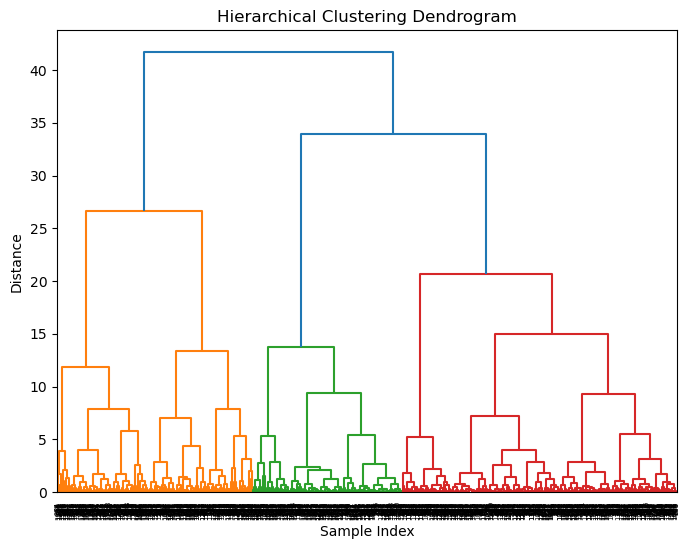

In [106]:
# Step 2: Plot the dendrogram
plt.figure(figsize=(8, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [107]:
# Step 1: Define the Agglomerative Clustering model
hc_model = AgglomerativeClustering(n_clusters=3, linkage='ward')  # Options: 'ward', 'complete', 'average', 'single'

# Step 2: Fit the model to the data
labels = hc_model.fit_predict(data1)

# Step 3: Print the cluster labels
print("Cluster Labels:", labels)

Cluster Labels: [2 1 0 ... 1 2 1]


In [9]:
a = np.array([[2,3],[2,1],[4,5]])
a[-1]

array([4, 5])

In [16]:
a[1,1]

1

In [99]:
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 3, 3, 2, 5])
model = LinearRegression() #Syntax
model.fit(X, y)
print(model.intercept_)
print(model.coef_)
X_new= np.array([[6], [7]])
predictions = model.predict(X_new)

0.6999999999999993
[0.7]


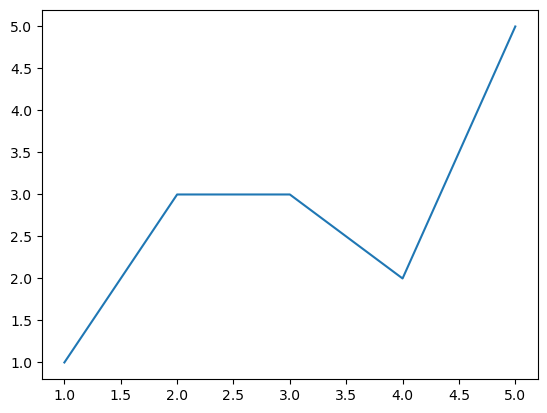

In [100]:
plt.plot(X,y)

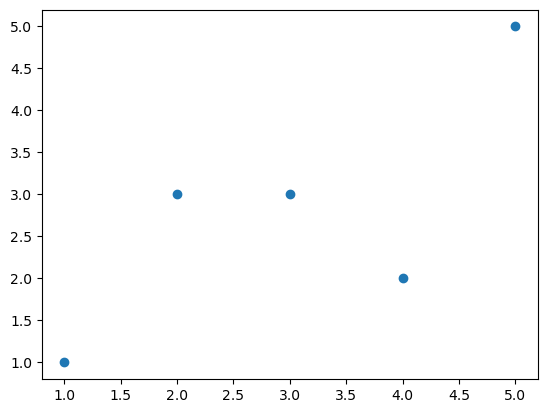

In [101]:
plt.scatter(X,y)

<Axes: >

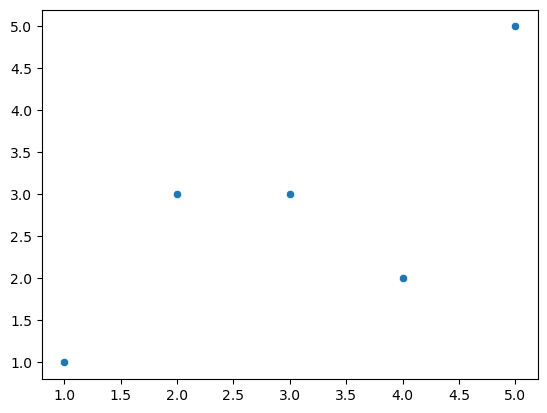

In [103]:
sns.scatterplot(x=X.flatten(),y=y)

<Axes: >

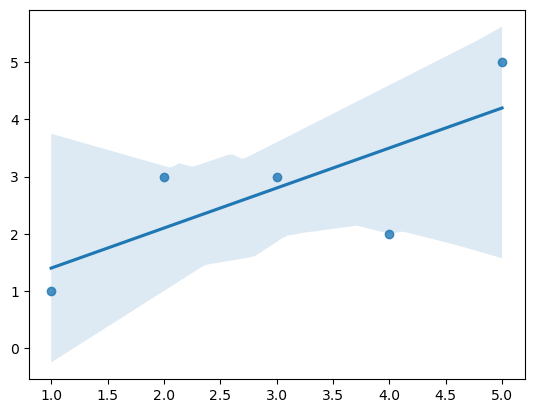

In [104]:
sns.regplot(x=X.flatten(),y=y)

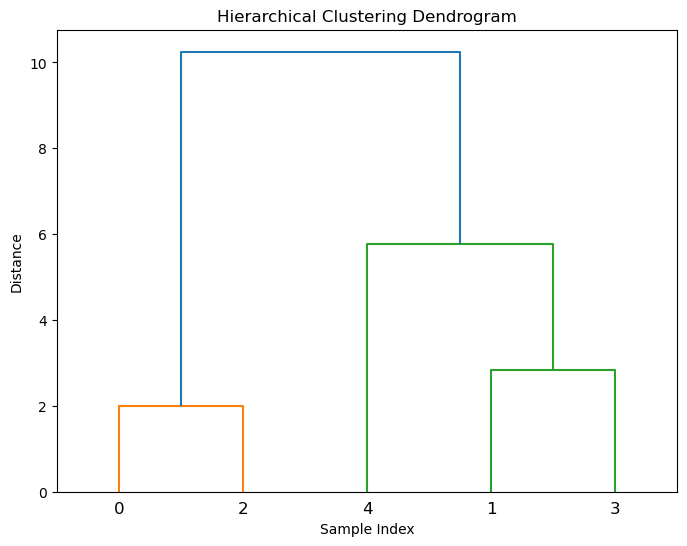

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Example data (replace with your dataset)
data = np.array([[1, 2], [3, 4], [1, 0], [5, 6], [8, 8]])

# Step 1: Compute linkage matrix
linkage_matrix = linkage(data, method='ward')  # Options: 'single', 'complete', 'average', 'ward'

# Step 2: Plot the dendrogram
plt.figure(figsize=(8, 6))
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [98]:
from sklearn.cluster import AgglomerativeClustering

# Step 1: Define the Agglomerative Clustering model
hc_model = AgglomerativeClustering(n_clusters=3, linkage='ward')  # Options: 'ward', 'complete', 'average', 'single'

# Step 2: Fit the model to the data
labels = hc_model.fit_predict(data)

# Step 3: Print the cluster labels
print("Cluster Labels:", labels)

Cluster Labels: [1 0 1 0 2]
